# Coupling topologies and phase–amplitude coupling

Notebook 01 used the coupling modes PRIN ships with. This one builds coupling
structures by hand. You will learn how the built-in topology builders lay out
their `(N, k)` neighbour tensors, how to drive a genuinely custom topology
through the Rust core with `CouplingMode.full`, what each `OscilloSim` coupling
mode costs, how phase–amplitude coupling (PAC) modulates a fast band from a
slow band's mean phase, how the Abrams–Strogatz cosine kernel is shaped, and
how Watts–Strogatz rewiring probability controls synchronization speed.

**Runtime budget: ~35 s on CPU** (measured on the maintainer host: Windows,
Python 3.14, torch 2.11.0 CPU). No GPU, no network access, every seed
explicit.

**Scale note.** The archived PRINet 3.0 notebook used N = 200–500 with 500
integration steps. The runs below use N = 64 for the hand-built dense topology
(dense coupling is O(N²) per step, so this is the expensive case), N = 512 for
the `OscilloSim` mode comparison, and N = 500 for the rewiring sweep. Those are
tutorial sizes; the qualitative behaviour — cluster synchronization, the
small-world shortcut effect — is what is being demonstrated, and no number here
is a measurement of PRIN's synchronization thresholds. The governed campaigns
live behind `prin.simulation_experiments`.

> **Read section 2's warning before using `CouplingMode.full`.** It contains a
> real API trap that silently ignores the coupling strength you pass.

**Prerequisites:** `pip install -e ".[all]"`.

In [1]:
import numpy as np
import torch

import prin
from prin.dynamics import (
    CouplingMode,
    KuramotoOscillator,
    OscillatorState,
    PhaseAmplitudeCoupling,
    RK4Integrator,
)
from prin.nn import PhaseAmplitudeCouplingLayer
from prin.simulation import (
    chimera_index,
    cosine_coupling_kernel,
    local_order_parameter,
)

# `import prin` forces matplotlib's non-interactive Agg backend, so the inline
# magic must follow it (see notebook 01).
%matplotlib inline

import matplotlib.pyplot as plt

DEVICE = "cpu"
SEED = 42

print(f"prin {prin.__version__} | torch {torch.__version__} | device {DEVICE}")

prin 0.3.0 | torch 2.11.0+cu128 | device cpu


## 1. Built-in topologies

Both builders return an `(N, k)` `int64` neighbour-index tensor — the same
layout `OscilloSim(coupling_weights=...)` and `local_order_parameter` expect.

`ring_topology(N, k)` is fully deterministic: oscillator *i* is joined to
`(i ± d) mod N` for `d = 1 … k/2`, laid out in the row as
`[-k/2, …, -1, +1, …, +k/2]`. `k` must be even and in `[2, N)`.

`small_world_topology(N, k, p_rewire, seed)` starts from that ring lattice and
rewires each edge with probability `p_rewire`, repairing any self-loop by
pointing it at `(i + 1) mod N`. At `p_rewire=0` it is exactly the ring; at
`p_rewire=1` it is a random graph.

ring_topology(64, 8)        -> shape (64, 8), dtype torch.int64
small_world_topology(..., p=0.2) -> shape (64, 8), dtype torch.int64
ring  row 0: [60, 61, 62, 63, 1, 2, 3, 4]
ring  row 1: [61, 62, 63, 0, 2, 3, 4, 5]
world row 0: [60, 61, 62, 5, 1, 2, 46, 4]
rewired edges in row 0: [5, 46]
p_rewire=0 reproduces the ring exactly: True
rejected: ring_topology(64, 7) (odd k) -> ValueError: invalid coupling matrix: k must be even for ring lattice, got 7
rejected: ring_topology(64, 0) (k < 2) -> ValueError: invalid coupling matrix: k must be >= 2, got 0
rejected: ring_topology(16, 16) (k >= N) -> ValueError: invalid coupling matrix: k must be < N, got k=16, N=16


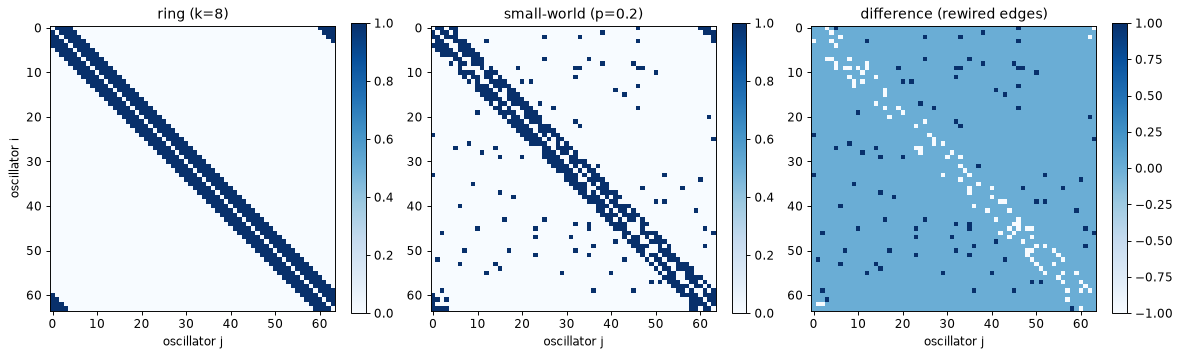

In [2]:
N_TOPO, K_TOPO = 64, 8
ring = prin.ring_topology(N_TOPO, K_TOPO, device=DEVICE)
world = prin.small_world_topology(N_TOPO, K_TOPO, p_rewire=0.2,
                                  device=DEVICE, seed=SEED)

print(f"ring_topology({N_TOPO}, {K_TOPO})        -> shape {tuple(ring.shape)}, "
      f"dtype {ring.dtype}")
print(f"small_world_topology(..., p=0.2) -> shape {tuple(world.shape)}, "
      f"dtype {world.dtype}")
print(f"ring  row 0: {ring[0].tolist()}")
print(f"ring  row 1: {ring[1].tolist()}")
print(f"world row 0: {world[0].tolist()}")
print(f"rewired edges in row 0: "
      f"{[int(w) for w, r in zip(world[0], ring[0], strict=True) if w != r]}")

p_ring = prin.ring_topology(N_TOPO, K_TOPO)
p_zero = prin.small_world_topology(N_TOPO, K_TOPO, p_rewire=0.0, seed=SEED)
print(f"p_rewire=0 reproduces the ring exactly: {torch.equal(p_ring, p_zero)}")

for label, args in (("odd k", (N_TOPO, 7)), ("k < 2", (N_TOPO, 0)),
                    ("k >= N", (16, 16))):
    try:
        prin.ring_topology(*args)
    except ValueError as exc:
        print(f"rejected: ring_topology{args} ({label}) -> ValueError: {exc}")


def adjacency(neighbours: torch.Tensor, n: int) -> np.ndarray:
    # Scatter the (N, k) neighbour list into a dense 0/1 matrix for plotting.
    matrix = np.zeros((n, n), dtype=np.float32)
    rows = np.repeat(np.arange(n), neighbours.shape[1])
    matrix[rows, neighbours.reshape(-1).numpy()] = 1.0
    return matrix


fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, matrix, title in (
    (axes[0], adjacency(ring, N_TOPO), f"ring (k={K_TOPO})"),
    (axes[1], adjacency(world, N_TOPO), "small-world (p=0.2)"),
    (axes[2], adjacency(world, N_TOPO) - adjacency(ring, N_TOPO),
     "difference (rewired edges)"),
):
    im = ax.imshow(matrix, cmap="Blues", interpolation="nearest",
                   vmin=-1.0 if ax is axes[2] else 0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xlabel("oscillator j")
    if ax is axes[0]:
        ax.set_ylabel("oscillator i")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.set_dpi(85)
plt.tight_layout()
plt.show()
plt.close(fig)

## 2. A custom two-cluster topology through the Rust core

`OscilloSim`'s five coupling modes cover the standard structures. For anything
else you go one level down, to `prin.dynamics`, and hand the Rust core a dense
coupling matrix:

```text
KuramotoOscillator(n, coupling_strength, decay_rate, freq_adaptation_rate,
                   CouplingMode.full(matrix=W.ravel()))
```

> **Trap — `coupling_strength` is ignored when you supply a matrix.** In
> `KuramotoOscillator::compute_full` (`crates/prin-dynamics/src/models.rs`),
> the per-edge weight is `k_ij = matrix[i * n + j]` when a matrix is present.
> The `coupling_strength * (1 / n)` term is used **only** in the no-matrix
> branch. So a `KuramotoOscillator(n, K, ...)` constructed with K = 0 and with
> K = 5000 over the same `W` produce bit-identical trajectories; the cell below
> demonstrates this rather than asking you to take it on trust. **Bake your
> coupling scale into `W` itself.**

Two further requirements, both of which raise a `TypeError` if you get them
wrong: `matrix` must be a **flat, row-major, contiguous float64 array of length
n·n** (passing the 2-D array directly fails), and `CouplingMode.full` takes it
as a keyword argument.

The topology here is two clusters of 32 oscillators with dense intra-cluster
coupling and a tunable inter-cluster weight `w_inter`, at fixed `w_intra = 1`.
Natural frequencies are drawn uniformly from [1, 10] rad/s for all 64
oscillators from an explicitly seeded generator, so the two clusters are *not*
frequency-differentiated — anything that separates them comes from the
coupling structure alone.

What the ratio sweep below shows, and what it does not:

- at `w_inter = 0` the clusters are two independent networks. Each locks
  internally (within-cluster *R* ≈ 0.99) but nothing ties their mean phases
  together, so the global *R* sits below the within-cluster value.
- a **small** `w_inter` (0.05–0.2) is enough to also lock the two cluster means
  to each other, and the global *R* rises to the within-cluster value.
- at `w_inter = w_intra` the block structure disappears: the population is
  homogeneous, and both within-cluster and global *R* fall, because the same
  total coupling is now spread over twice as many edges with no cluster
  identity to exploit.

This is a single-seed, N = 64, T = 20 s demonstration of how to *drive* a
custom matrix. It is not a study of cluster synchronization; the transition
structure needs a sweep over `w_inter`, N, and seed that belongs in a governed
campaign, not a tutorial.

In [3]:
N_CLUSTER = 64
HALF = N_CLUSTER // 2
STEPS, DT = 2_000, 0.01


def two_cluster_matrix(w_intra: float, w_inter: float) -> np.ndarray:
    # Dense symmetric block structure: coupling lives entirely in the entries,
    # because CouplingMode.full(matrix=...) ignores coupling_strength.
    matrix = np.full((N_CLUSTER, N_CLUSTER), w_inter, dtype=np.float64)
    matrix[:HALF, :HALF] = w_intra
    matrix[HALF:, HALF:] = w_intra
    np.fill_diagonal(matrix, 0.0)
    return matrix


def run_clusters(matrix: np.ndarray, coupling_strength: float) -> dict[str, object]:
    rng = np.random.default_rng(SEED)
    frequency = rng.uniform(1.0, 10.0, N_CLUSTER)
    phase = rng.uniform(0.0, 2 * np.pi, N_CLUSTER)
    state = OscillatorState(phase, np.ones(N_CLUSTER), frequency)
    model = KuramotoOscillator(
        N_CLUSTER, coupling_strength, 0.0, 0.0,
        CouplingMode.full(matrix=np.ascontiguousarray(matrix.ravel())),
    )
    integrator = RK4Integrator()
    global_r, cluster_a, cluster_b = [], [], []
    for step in range(STEPS):
        state = integrator.step(model, state, DT)
        if step % 20 == 0:
            global_r.append(float(prin.kuramoto_order_parameter(state.phase)))
            cluster_a.append(float(prin.kuramoto_order_parameter(state.phase[:HALF])))
            cluster_b.append(float(prin.kuramoto_order_parameter(state.phase[HALF:])))
    return {
        "global": np.array(global_r),
        "a": np.array(cluster_a),
        "b": np.array(cluster_b),
        "final_phase": state.phase.copy(),
    }


print("coupling_strength is inert once a matrix is supplied:")
reference = two_cluster_matrix(1.0, 0.05)
for coupling_strength in (0.0, 1.0, 5000.0):
    out = run_clusters(reference, coupling_strength)
    print(f"  K={coupling_strength:<8} R_global(final)={out['global'][-1]:.10f}  "
          f"R_A={out['a'][-1]:.10f}  R_B={out['b'][-1]:.10f}")

print()
print("the same pattern scaled into the matrix does change the outcome:")
for scale in (0.25, 1.0, 4.0):
    out = run_clusters(reference * scale, 1.0)
    print(f"  W * {scale:<5} R_global(final)={out['global'][-1]:.4f}  "
          f"R_A={out['a'][-1]:.4f}  R_B={out['b'][-1]:.4f}")

coupling_strength is inert once a matrix is supplied:


  K=0.0      R_global(final)=0.9897775301  R_A=0.9898793416  R_B=0.9899310034


  K=1.0      R_global(final)=0.9897775301  R_A=0.9898793416  R_B=0.9899310034


  K=5000.0   R_global(final)=0.9897775301  R_A=0.9898793416  R_B=0.9899310034

the same pattern scaled into the matrix does change the outcome:


  W * 0.25  R_global(final)=0.9979  R_A=0.9995  R_B=0.9997


  W * 1.0   R_global(final)=0.9898  R_A=0.9899  R_B=0.9899


  W * 4.0   R_global(final)=0.0405  R_A=0.4384  R_B=0.3658


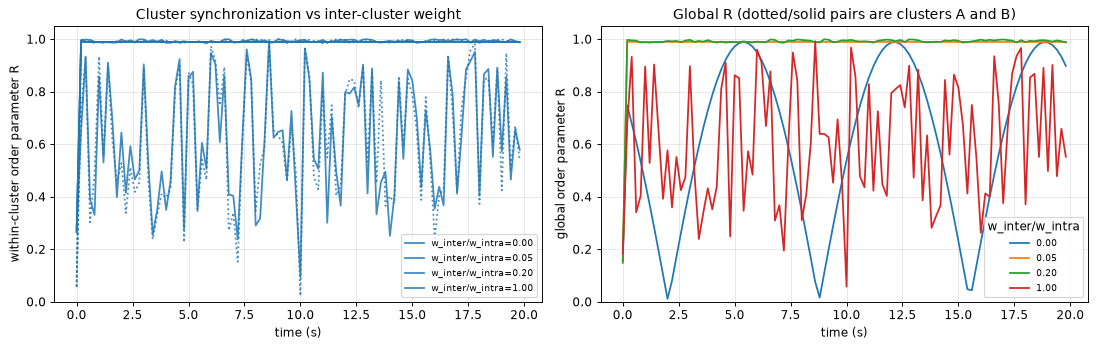

 w_inter/w_intra  R_A (late)  R_B (late)  R_global (late)
            0.00      0.9894      0.9894           0.7057
            0.05      0.9899      0.9899           0.9898
            0.20      0.9940      0.9933           0.9936
            1.00      0.6394      0.6495           0.6345


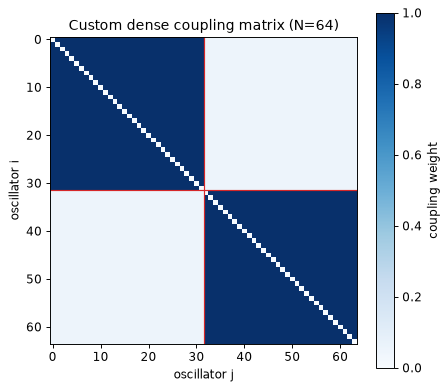

matrix handed to Rust: flat row-major float64, length 4096 = 64 x 64, contiguous=True


In [4]:
RATIOS = (0.0, 0.05, 0.2, 1.0)
runs = {}
for ratio in RATIOS:
    runs[ratio] = run_clusters(two_cluster_matrix(1.0, ratio), 1.0)

time_axis = np.arange(len(next(iter(runs.values()))["global"])) * 20 * DT

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ratio in RATIOS:
    axes[0].plot(time_axis, runs[ratio]["a"], color="#1f77b4", alpha=0.85,
                 label=f"w_inter/w_intra={ratio:.2f}")
    axes[0].plot(time_axis, runs[ratio]["b"], color="#1f77b4", alpha=0.85,
                 linestyle=":")
axes[0].set_xlabel("time (s)")
axes[0].set_ylabel("within-cluster order parameter R")
axes[0].set_title("Cluster synchronization vs inter-cluster weight")
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

for ratio in RATIOS:
    axes[1].plot(time_axis, runs[ratio]["global"], label=f"{ratio:.2f}")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("global order parameter R")
axes[1].set_title("Global R (dotted/solid pairs are clusters A and B)")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8, title="w_inter/w_intra")
fig.set_dpi(85)
plt.tight_layout()
plt.show()
plt.close(fig)

print(f"{'w_inter/w_intra':>16} {'R_A (late)':>11} {'R_B (late)':>11} "
      f"{'R_global (late)':>16}")
late = slice(len(time_axis) // 2, None)
for ratio in RATIOS:
    run = runs[ratio]
    print(f"{ratio:>16.2f} {run['a'][late].mean():>11.4f} {run['b'][late].mean():>11.4f} "
          f"{run['global'][late].mean():>16.4f}")

matrix = two_cluster_matrix(1.0, 0.05)
fig, ax = plt.subplots(figsize=(5.4, 4.8))
im = ax.imshow(matrix, cmap="Blues", interpolation="nearest")
ax.axhline(HALF - 0.5, color="#d62728", linewidth=1)
ax.axvline(HALF - 0.5, color="#d62728", linewidth=1)
ax.set_title(f"Custom dense coupling matrix (N={N_CLUSTER})")
ax.set_xlabel("oscillator j")
ax.set_ylabel("oscillator i")
fig.colorbar(im, ax=ax, label="coupling weight")
fig.set_dpi(85)
plt.tight_layout()
plt.show()
plt.close(fig)
print(f"matrix handed to Rust: flat row-major float64, length {matrix.size} "
      f"= {N_CLUSTER} x {N_CLUSTER}, contiguous="
      f"{np.ascontiguousarray(matrix.ravel()).flags['C_CONTIGUOUS']}")

## 3. What each `OscilloSim` coupling mode costs

Notebook 01 compared the modes' *dynamics*. This compares their *cost* at
matched N, K, and step count, which is the question you actually face when
choosing one. `"auto"` is not a sixth mode — it resolves to `csr` below 1 000
oscillators, `sparse_knn` from 1 000 to 100 000, and `mean_field` above that.

`"full"` is rejected outright: a dense all-to-all matrix is what
`"mean_field"` already computes in O(N) per step by reducing to the global
order parameter, so PRIN never materializes it. If you genuinely need a dense
custom matrix, use `prin.dynamics` as in section 2.

requested     resolved       R_final   wall s    osc-steps/s
csr           csr             0.9301    0.042     61,204,192
mean_field    mean_field      0.9199    0.038     66,987,299
ring          ring            0.0955    0.099     25,788,072
small_world   small_world     0.4045    0.109     23,379,124
sparse_knn    sparse_knn      0.9413    0.085     30,237,709

'auto' at N=512 resolves to: csr
rejected: coupling_mode='full' -> ValueError: Unknown coupling_mode 'full'; expected one of ['auto', 'csr', 'mean_field', 'ring', 'small_world', 'sparse_knn']


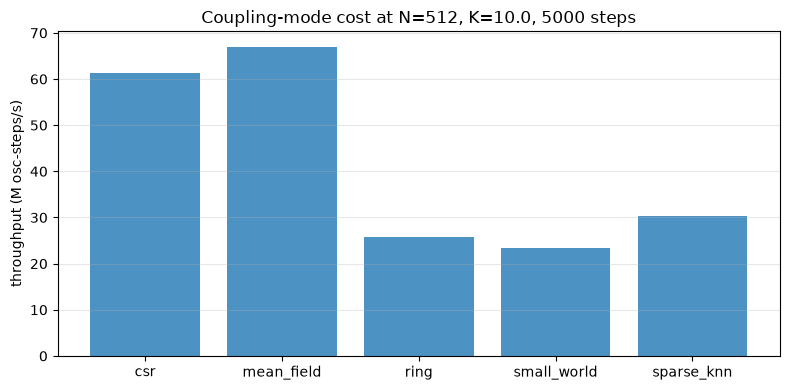

In [5]:
N_MODE, K_MODE, STEPS_MODE = 512, 10.0, 5_000
mode_rows = []

for mode in ("csr", "mean_field", "ring", "small_world", "sparse_knn"):
    mode_sim = prin.OscilloSim(
        n_oscillators=N_MODE, coupling_strength=K_MODE, coupling_mode=mode,
        k_neighbors=10, p_rewire=0.1, integrator="euler", device=DEVICE, seed=SEED,
    )
    mode_res = mode_sim.run(n_steps=STEPS_MODE, dt=0.01)
    mode_rows.append((mode, mode_res.coupling_mode, mode_res.order_parameter[-1],
                      mode_res.wall_time_s, mode_res.throughput))

print(f"{'requested':<13} {'resolved':<13} {'R_final':>8} {'wall s':>8} "
      f"{'osc-steps/s':>14}")
for requested, resolved, r_final, wall, throughput in mode_rows:
    print(f"{requested:<13} {resolved:<13} {r_final:>8.4f} {wall:>8.3f} "
          f"{throughput:>14,.0f}")

auto = prin.OscilloSim(n_oscillators=N_MODE, coupling_mode="auto", device=DEVICE,
                       seed=SEED)
print()
print(f"'auto' at N={N_MODE} resolves to: {auto.coupling_mode}")
try:
    prin.OscilloSim(n_oscillators=N_MODE, coupling_mode="full", device=DEVICE, seed=SEED)
except ValueError as exc:
    print(f"rejected: coupling_mode='full' -> ValueError: {exc}")

fig, ax = plt.subplots(figsize=(8, 4))
labels = [row[0] for row in mode_rows]
ax.bar(labels, [row[4] / 1e6 for row in mode_rows], color="#1f77b4", alpha=0.8)
ax.set_ylabel("throughput (M osc-steps/s)")
ax.set_title(f"Coupling-mode cost at N={N_MODE}, K={K_MODE}, "
             f"{STEPS_MODE} steps")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
plt.close(fig)

## 4. Phase–amplitude coupling (PAC)

PAC is how PRIN couples bands of different frequency: a slow band's phase
modulates a fast band's amplitude. The Rust owner is
`prin.dynamics.PhaseAmplitudeCoupling`, and its rule is a single closed form
(`crates/prin-dynamics/src/pac.rs`):

```text
A_out = A_in * [1 + m * cos(mean(slow_phase) + offset)]
```

clamped to `[1e-6, 10]`. Two consequences worth internalizing:

- the slow band is **reduced to its mean phase** before modulating, so passing
  a vector of slow phases does *not* give one modulated amplitude per slow
  oscillator — every fast oscillator receives the same factor;
- because the factor is `1 + m cos(...)`, the modulated amplitude is largest at
  `mean(slow_phase) + offset = 0` and smallest at `pi`, where it reaches
  `A_in * (1 - m)`.

The cell below sweeps the mean slow phase, overlays the closed form, and checks
the two agree — then repeats it through the differentiable
`prin.nn.PhaseAmplitudeCouplingLayer` used inside networks.

One caveat about that layer, which the cell demonstrates rather than asserts:
its `forward` rebuilds the Rust bridge from
`modulation_depth.detach().clamp(0, 1)`, so although `modulation_depth` is
registered as an `nn.Parameter`, it receives **no gradient**. The
differentiable path covers `slow_phase` and `fast_amplitude` only. If you need
the depth itself to be learned, drive `prin.dynamics.PhaseAmplitudeCoupling`
through your own `torch.autograd.Function` (notebook 04 shows how) rather than
assuming the layer's parameter is trainable.

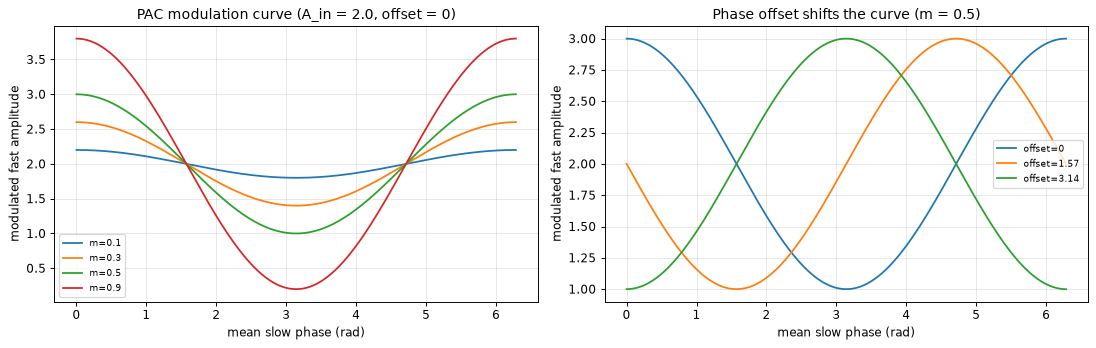

max |measured - closed form| over 240 phases x 4 depths: 0.000e+00
modulation_depth property: 0.5
modulate([0, pi/2, pi, 3pi/2], ones(4), 0) = [0.646447, 0.646447, 0.646447, 0.646447]
modulate(full(4, 3pi/4),       ones(4), 0) = [0.646447, 0.646447, 0.646447, 0.646447]
expected factor 1 + 0.5*cos(3pi/4) = 0.646447

PhaseAmplitudeCouplingLayer: slow_phase (8, 16), fast_amplitude (8, 64) -> (8, 64)
named_parameters: [('modulation_depth', ())]
gradient reaches fast_amplitude: True (norm 17.6375)
gradient on modulation_depth : None
  -> forward() rebuilds the Rust bridge from `modulation_depth.detach().clamp(0, 1)`, so the declared-learnable
     depth is not on the autograd path; only slow_phase and fast_amplitude are.


In [6]:
PHASES = np.linspace(0.0, 2 * np.pi, 240)
FAST_AMPLITUDE = np.array([2.0])
DEPTHS = (0.1, 0.3, 0.5, 0.9)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
worst_error = 0.0
for depth in DEPTHS:
    pac = PhaseAmplitudeCoupling(depth)
    measured = np.array([
        pac.modulate(np.array([phi]), FAST_AMPLITUDE, 0.0)[0] for phi in PHASES
    ])
    closed_form = FAST_AMPLITUDE[0] * (1.0 + depth * np.cos(PHASES))
    worst_error = max(worst_error, float(np.abs(measured - closed_form).max()))
    axes[0].plot(PHASES, measured, label=f"m={depth}")
axes[0].set_xlabel("mean slow phase (rad)")
axes[0].set_ylabel("modulated fast amplitude")
axes[0].set_title("PAC modulation curve (A_in = 2.0, offset = 0)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

pac_offset = PhaseAmplitudeCoupling(0.5)
for offset in (0.0, np.pi / 2, np.pi):
    shifted = np.array([
        pac_offset.modulate(np.array([phi]), FAST_AMPLITUDE, offset)[0]
        for phi in PHASES
    ])
    axes[1].plot(PHASES, shifted, label=f"offset={offset:.3g}")
axes[1].set_xlabel("mean slow phase (rad)")
axes[1].set_ylabel("modulated fast amplitude")
axes[1].set_title("Phase offset shifts the curve (m = 0.5)")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)
fig.set_dpi(85)
plt.tight_layout()
plt.show()
plt.close(fig)

print(f"max |measured - closed form| over {len(PHASES)} phases x "
      f"{len(DEPTHS)} depths: {worst_error:.3e}")
print(f"modulation_depth property: {PhaseAmplitudeCoupling(0.5).modulation_depth}")

# The slow band is collapsed to its mean phase: four different phase vectors
# with the same mean give the same output, and one vector of four distinct
# phases gives one common factor, not four.
pac_mean = PhaseAmplitudeCoupling(0.5)
spread = np.array([0.0, np.pi / 2, np.pi, 3 * np.pi / 2])
same_mean = np.full(4, spread.mean())
print(f"modulate([0, pi/2, pi, 3pi/2], ones(4), 0) = "
      f"{np.round(pac_mean.modulate(spread, np.ones(4), 0.0), 6).tolist()}")
print(f"modulate(full(4, 3pi/4),       ones(4), 0) = "
      f"{np.round(pac_mean.modulate(same_mean, np.ones(4), 0.0), 6).tolist()}")
print(f"expected factor 1 + 0.5*cos(3pi/4) = "
      f"{1.0 + 0.5 * np.cos(spread.mean()):.6f}")

# The differentiable layer used inside networks.
pac_layer = PhaseAmplitudeCouplingLayer(initial_depth=0.3)
pac_gen = torch.Generator().manual_seed(SEED)
slow_phase = torch.rand(8, 16, generator=pac_gen) * 2 * torch.pi
fast_amp = (torch.rand(8, 64, generator=pac_gen) + 0.5).requires_grad_(True)
modulated = pac_layer(slow_phase, fast_amp)
modulated.sum().backward()
print()
print(f"PhaseAmplitudeCouplingLayer: slow_phase {tuple(slow_phase.shape)}, "
      f"fast_amplitude {tuple(fast_amp.shape)} -> {tuple(modulated.shape)}")
print(f"named_parameters: "
      f"{[(n, tuple(p.shape)) for n, p in pac_layer.named_parameters()]}")
print(f"gradient reaches fast_amplitude: {fast_amp.grad is not None} "
      f"(norm {float(fast_amp.grad.norm()):.4f})")
print(f"gradient on modulation_depth : {pac_layer.modulation_depth.grad}")
print("  -> forward() rebuilds the Rust bridge from "
      "`modulation_depth.detach().clamp(0, 1)`, so the declared-learnable")
print("     depth is not on the autograd path; only slow_phase and "
      "fast_amplitude are.")

## 5. The Abrams–Strogatz cosine kernel

Chimera states were first shown on a ring whose coupling falls off smoothly
with distance (Abrams & Strogatz 2004). `cosine_coupling_kernel(n, k, A)`
returns the per-edge weights

```text
G(d) = (1 + A * cos(2 pi d / n)) / (2 pi)
```

for ring distance `d`, normalized so each row sums to 1, and broadcasts that
single row to all `n` oscillators. `A` is the asymmetry parameter in `[0, 1]`:
`A = 0` gives uniform coupling, and `A → 1` sharpens the preference for near
neighbours.

Because the ring row is ordered `[-k/2, …, -1, +1, …, +k/2]`, the *row index*
is not the distance — the profile below is plotted against `d` so the peak at
`d = 1` is where you would expect it.

kernel shape (128, 20), dtype torch.float32
every row identical: True
row sums to 1.000000
row index      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
neighbour index: [118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
ring distance d: [10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


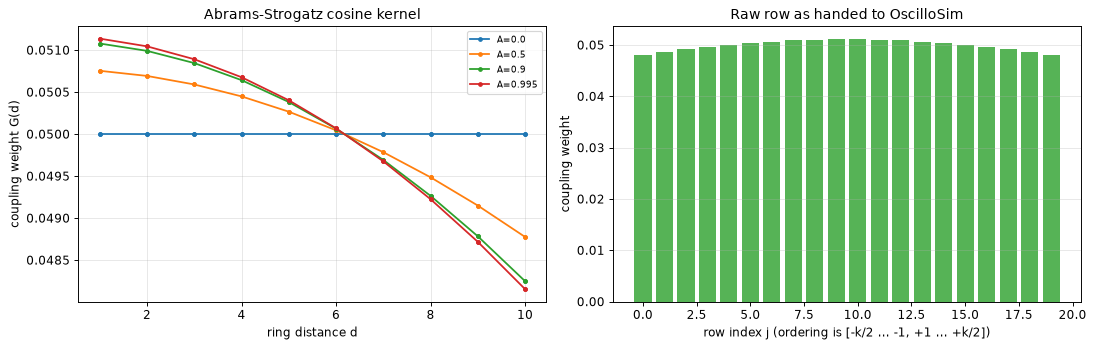


ring, uniform weights : R_final=0.2670
ring, cosine kernel   : R_final=0.0714
cosine-kernel run diagnostics: chimera_index=0.0859, mean local R=0.7758, std local R=0.1677
Reading these honestly: a LOW global R together with a HIGH mean local R
is the phase-gradient (twisted-state) signature -- locally coherent,
globally incoherent. A chimera state is different: it needs a LOCALIZED
incoherent domain inside a coherent background, which shows up as a
large std of local R and a chimera_index near 0.5, not near 0 or 1.
One seed at one K cannot establish either regime; that is what the
campaign behind prin.simulation_experiments is for.


In [7]:
N_KERNEL, K_KERNEL = 128, 20
kernel = cosine_coupling_kernel(N_KERNEL, K_KERNEL, A=0.995, device=DEVICE)
neighbours = prin.ring_topology(N_KERNEL, K_KERNEL, device=DEVICE)

row = kernel[0]
offsets = ((neighbours[0] - 0) + N_KERNEL // 2) % N_KERNEL - N_KERNEL // 2
distance = np.abs(offsets.numpy())
print(f"kernel shape {tuple(kernel.shape)}, dtype {kernel.dtype}")
print(f"every row identical: {bool(torch.all(kernel == row.unsqueeze(0)))}")
print(f"row sums to {float(row.sum()):.6f}")
print(f"row index      : {list(range(K_KERNEL))}")
print(f"neighbour index: {neighbours[0].tolist()}")
print(f"ring distance d: {distance.tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
order = np.argsort(distance)
for A in (0.0, 0.5, 0.9, 0.995):
    profile = cosine_coupling_kernel(N_KERNEL, K_KERNEL, A=A, device=DEVICE)[0]
    axes[0].plot(distance[order], profile.numpy()[order], "o-",
                 markersize=3, label=f"A={A}")
axes[0].set_xlabel("ring distance d")
axes[0].set_ylabel("coupling weight G(d)")
axes[0].set_title("Abrams-Strogatz cosine kernel")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].bar(np.arange(K_KERNEL), row.numpy(), alpha=0.8, color="#2ca02c")
axes[1].set_xlabel("row index j (ordering is [-k/2 ... -1, +1 ... +k/2])")
axes[1].set_ylabel("coupling weight")
axes[1].set_title("Raw row as handed to OscilloSim")
axes[1].grid(alpha=0.3, axis="y")
fig.set_dpi(85)
plt.tight_layout()
plt.show()
plt.close(fig)

# The kernel is accepted directly as per-edge coupling weights.
weighted = prin.OscilloSim(
    n_oscillators=N_KERNEL, coupling_strength=10.0, coupling_mode="ring",
    k_neighbors=K_KERNEL, coupling_weights=kernel, integrator="euler",
    device=DEVICE, seed=SEED,
)
weighted_res = weighted.run(n_steps=20_000, dt=0.005)
plain = prin.OscilloSim(
    n_oscillators=N_KERNEL, coupling_strength=10.0, coupling_mode="ring",
    k_neighbors=K_KERNEL, integrator="euler", device=DEVICE, seed=SEED,
)
plain_res = plain.run(n_steps=20_000, dt=0.005)

print()
print(f"ring, uniform weights : R_final={plain_res.order_parameter[-1]:.4f}")
print(f"ring, cosine kernel   : R_final={weighted_res.order_parameter[-1]:.4f}")
chi = chimera_index(weighted_res.final_phase, neighbours)
local_r = local_order_parameter(weighted_res.final_phase, neighbours)
print(f"cosine-kernel run diagnostics: chimera_index={chi:.4f}, "
      f"mean local R={float(local_r.mean()):.4f}, "
      f"std local R={float(local_r.std()):.4f}")
print("Reading these honestly: a LOW global R together with a HIGH mean local R")
print("is the phase-gradient (twisted-state) signature -- locally coherent,")
print("globally incoherent. A chimera state is different: it needs a LOCALIZED")
print("incoherent domain inside a coherent background, which shows up as a")
print("large std of local R and a chimera_index near 0.5, not near 0 or 1.")
print("One seed at one K cannot establish either regime; that is what the")
print("campaign behind prin.simulation_experiments is for.")

## 6. Rewiring probability vs synchronization speed

The Watts–Strogatz claim is that a few long-range shortcuts dramatically shorten
the time to synchronize while preserving local structure. The sweep below
measures the first time at which the global order parameter exceeds 0.9, as a
function of `p_rewire`, at K = 20.

`p_rewire = 0` is a pure ring: with only local contacts the network cannot
absorb the frequency spread, so it never reaches 0.9 within the simulated
window and the bar is plotted at the window length. That non-monotonic
low-`p` behaviour is a property of the ring, not noise.

simulated window: 200.0 s (20000 steps at dt=0.01)
 p_rewire   time to R>0.9 (s)   R_final
     0.00             > 200.0    0.1047
     0.01             > 200.0    0.0212
     0.05             > 200.0    0.8498
     0.10                3.10    0.9331
     0.30                0.80    0.9801
     0.50                0.60    0.9864
     1.00                0.50    0.9880


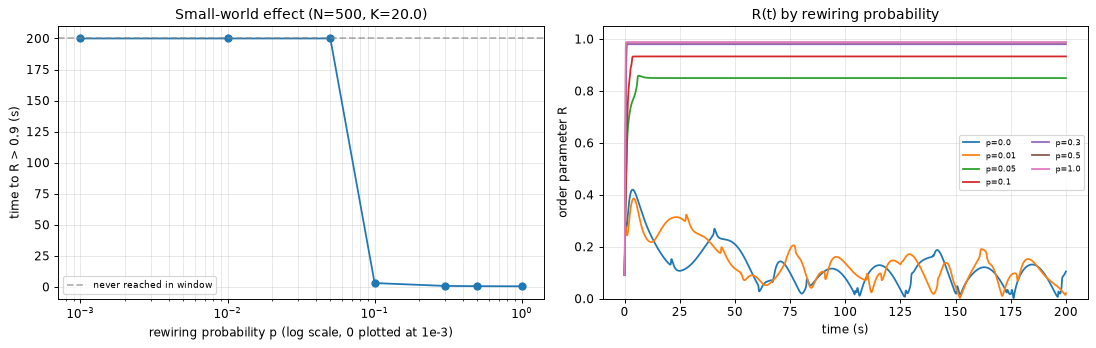

In [8]:
N_REWIRE, K_REWIRE, STEPS_REWIRE, DT_REWIRE = 500, 20.0, 20_000, 0.01
RECORD_INTERVAL = 10
P_VALUES = (0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0)
THRESHOLD = 0.9
window_s = STEPS_REWIRE * DT_REWIRE

rewire_rows = []
for p in P_VALUES:
    rewire_sim = prin.OscilloSim(
        n_oscillators=N_REWIRE, coupling_strength=K_REWIRE,
        coupling_mode="small_world", k_neighbors=10, p_rewire=p,
        integrator="euler", device=DEVICE, seed=SEED,
    )
    rewire_res = rewire_sim.run(
        n_steps=STEPS_REWIRE, dt=DT_REWIRE, record_trajectory=True,
        record_interval=RECORD_INTERVAL,
    )
    series = np.asarray(rewire_res.order_parameter)
    crossing = np.flatnonzero(series > THRESHOLD)
    sync_time = float(crossing[0]) * RECORD_INTERVAL * DT_REWIRE if crossing.size else None
    rewire_rows.append((p, sync_time, float(series[-1]), rewire_res.order_parameter))

print(f"simulated window: {window_s:.1f} s "
      f"({STEPS_REWIRE} steps at dt={DT_REWIRE})")
print(f"{'p_rewire':>9} {'time to R>0.9 (s)':>19} {'R_final':>9}")
for p, sync_time, r_final, _ in rewire_rows:
    shown = f"{sync_time:>19.2f}" if sync_time is not None else f"{'> ' + format(window_s, '.1f'):>19}"
    print(f"{p:>9.2f} {shown} {r_final:>9.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
plot_times = [row[1] if row[1] is not None else window_s for row in rewire_rows]
axes[0].semilogx([max(p, 1e-3) for p, *_ in rewire_rows], plot_times, "o-",
                 color="#1f77b4")
axes[0].axhline(window_s, color="gray", linestyle="--", alpha=0.6,
                label="never reached in window")
axes[0].set_xlabel("rewiring probability p (log scale, 0 plotted at 1e-3)")
axes[0].set_ylabel(f"time to R > {THRESHOLD} (s)")
axes[0].set_title(f"Small-world effect (N={N_REWIRE}, K={K_REWIRE})")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend(fontsize=8)

for p, _, _, series in rewire_rows:
    axis = np.arange(len(series)) * RECORD_INTERVAL * DT_REWIRE
    axes[1].plot(axis, series, label=f"p={p}")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("order parameter R")
axes[1].set_title("R(t) by rewiring probability")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=7, ncol=2)
fig.set_dpi(85)
plt.tight_layout()
plt.show()
plt.close(fig)

## Summary

| Topic | API used |
|---|---|
| Ring lattice | `prin.ring_topology(N, k)` → `(N, k)` int64, deterministic |
| Watts–Strogatz | `prin.small_world_topology(N, k, p_rewire, seed)` |
| Custom dense topology | `CouplingMode.full(matrix=np.ascontiguousarray(W.ravel()))` + `KuramotoOscillator` + `RK4Integrator` |
| Direct state construction | `OscillatorState(phase, amplitude, frequency)` |
| Coupling-mode cost | `OscilloSim(coupling_mode=...).run(...)` → `wall_time_s`, `throughput`, `coupling_mode` |
| PAC (Rust owner) | `PhaseAmplitudeCoupling(m).modulate(slow_phase, fast_amplitude, offset)` |
| PAC (differentiable) | `prin.nn.PhaseAmplitudeCouplingLayer(initial_depth)` |
| Cosine kernel | `prin.simulation.cosine_coupling_kernel(n, k, A)` → `(n, k)` float32, rows sum to 1 |
| Per-edge weights | `OscilloSim(coupling_mode="ring", coupling_weights=...)` |
| Chimera diagnostics | `prin.simulation.{chimera_index, local_order_parameter}` |
| Order parameter | `prin.kuramoto_order_parameter` |

The three traps this notebook exists to save you from:

1. `CouplingMode.full(matrix=...)` **ignores `coupling_strength`** — scale the
   matrix instead.
2. `CouplingMode.full` needs a **flat, contiguous, row-major float64** array of
   length n·n; the 2-D array raises `TypeError`.
3. `PhaseAmplitudeCoupling.modulate` reduces the slow band to its **mean
   phase**, so it is not a per-oscillator modulation of the slow band.

Next: [`04_torch_bridge.ipynb`](04_torch_bridge.ipynb) shows how all of this
Rust numerics is reached from a PyTorch training loop.